## Konwolucyjne sieci neuronowe

Przeprowadzone testy konwolucyjnych sieci neuronowych na datasecie load_digits z scikit-learn w ramach klasyfikacji obrazów uzyskały wysokie wyniki dokładności. W pierwotnym modelu dokładność wzrasta bardzo szybko, a końcowy wynik dokładności dla liczby epok 10 wynosił ok. 97%. Dodanie warstw dropout pozwoliło na szybsze uzyskanie wysokiego wyniku dla wyniku walidacyjnego w mniejszej liczbie epok (epoka 6 ok 97%). Zmiana funkcji aktywacji w warstwach konwolucyjnych z ReLU na Tanh przyniosła kolejne pozytywne efekty, osiągając nawet powyzej 98% dokładności. 
Dodatkowo została zrealizowana macierz pomyłek pokazująca, ze błędy były sporadyczne, a z wyraźnych błedów model zbyt często chciał przewidywać liczbę 9 zamiast rzeczywistej. 

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


digits = load_digits()
X = digits.images
y = digits.target
class_names = digits.target_names
X = X / 16.0
X = X[..., tf.newaxis]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)


In [37]:
model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
tf.keras.layers.MaxPooling2D((2, 2)),
tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 1, 1, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,626 (92.29 KB)

 Trainable params: 23,626 (92.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3918 - loss: 2.1149 - val_accuracy: 0.6861 - val_loss: 1.7789
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7557 - loss: 1.2291 - val_accuracy: 0.8667 - val_loss: 0.7370
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8984 - loss: 0.4869 - val_accuracy: 0.9056 - val_loss: 0.3975
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9311 - loss: 0.2800 - val_accuracy: 0.9361 - val_loss: 0.2817
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9457 - loss: 0.2079 - val_accuracy: 0.9361 - val_loss: 0.2418
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9562 - loss: 0.1825 - val_accuracy: 0.9278 - val_loss: 0.2597
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9638 - loss: 0.1451 - val_accuracy: 0.9444 - val_loss: 0.1963
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9631 - loss: 0.1310 - val_accuracy: 0.9389 - val_loss:

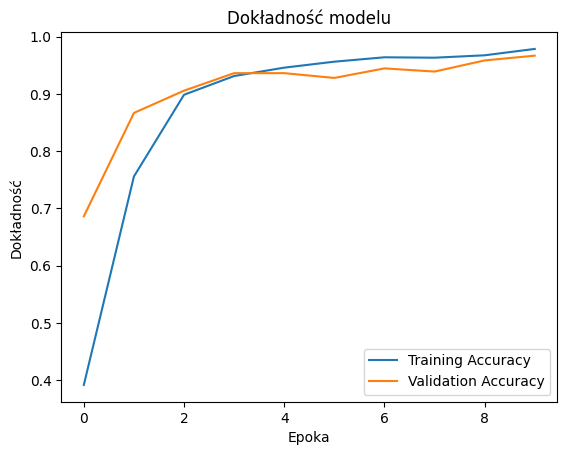

In [38]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.title('Dokładność modelu')
plt.show()

In [40]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.1350 
Test accuracy: 0.9666666388511658


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


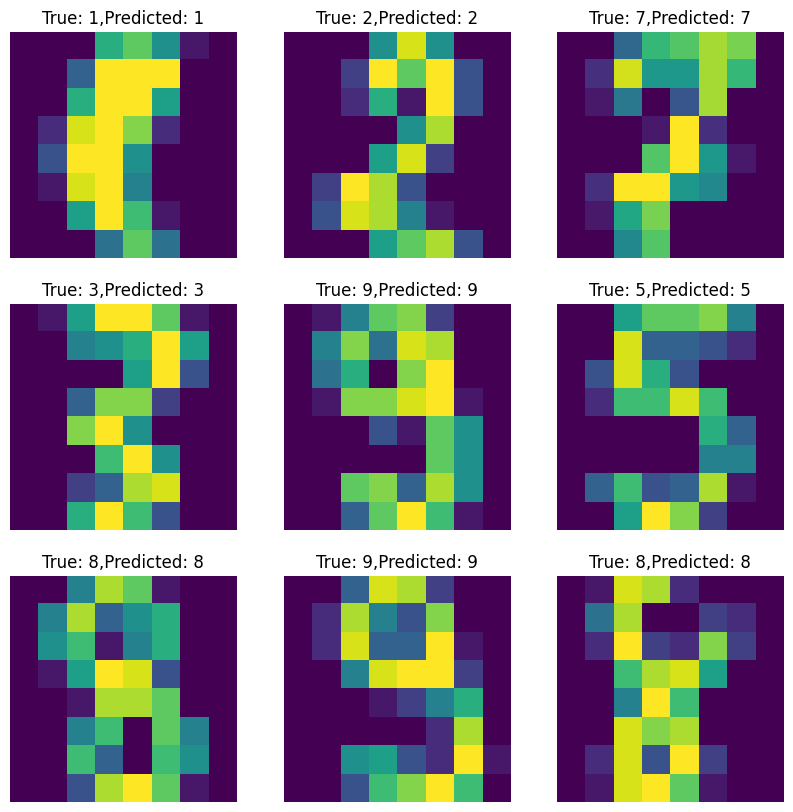

In [41]:
predictions = model.predict(X_test)
plt.figure(figsize=(10, 10))
for i in range(9):
 plt.subplot(3, 3, i + 1)
 plt.imshow(X_test[i])
 plt.title(f"True: {class_names[int(y_test[i])]}," +
 f"Predicted: {class_names[tf.argmax(predictions[i])]}")
 plt.axis("off")
plt.show()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 1, 1, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,626 (92.29 KB)

 Trainable params: 23,626 (92.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2554 - loss: 2.1685 - val_accuracy: 0.5889 - val_loss: 1.8623
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6430 - loss: 1.3772 - val_accuracy: 0.7917 - val_loss: 0.8284
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8128 - loss: 0.6809 - val_accuracy: 0.9083 - val_loss: 0.4215
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8747 - loss: 0.4429 - val_accuracy: 0.9222 - val_loss: 0.2979
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9005 - loss: 0.3487 - val_accuracy: 0.9417 - val_loss: 0.2374
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9033 - loss: 0.3059 - val_accuracy: 0.9472 - val_loss: 0.2035
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9339 - loss: 0.2267 - val_accuracy: 0.9528 - val_loss: 0.1772
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9228 - loss: 0.2349 - val_accuracy: 0.9528 - val_loss:

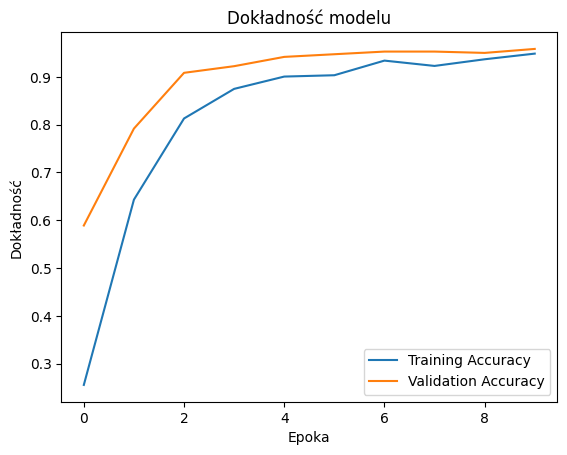

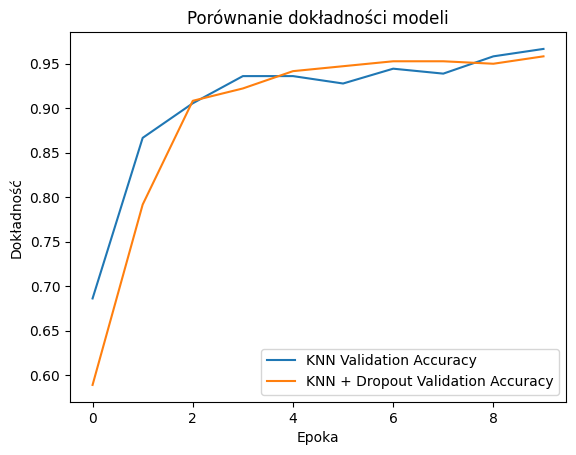

In [48]:
model_dropout = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
tf.keras.layers.MaxPooling2D((2, 2)),
tf.keras.layers.Dropout(0.25),
tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
tf.keras.layers.Dropout(0.10),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

model_dropout.summary()

model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

plt.plot(history_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.title('Dokładność modelu z wykorzystaniem dropout')
plt.show()

plt.plot(history.history['val_accuracy'], label='KNN Validation Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='KNN + Dropout Validation Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.title('Porównanie dokładności modeli')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)              │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 1, 1, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,626 (92.29 KB)

 Trainable params: 23,626 (92.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5122 - loss: 1.8640 - val_accuracy: 0.7222 - val_loss: 1.3435
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8372 - loss: 0.8355 - val_accuracy: 0.8833 - val_loss: 0.5531
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9179 - loss: 0.3663 - val_accuracy: 0.9194 - val_loss: 0.3068
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9450 - loss: 0.2263 - val_accuracy: 0.9361 - val_loss: 0.2324
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9589 - loss: 0.1611 - val_accuracy: 0.9389 - val_loss: 0.2031
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9736 - loss: 0.1212 - val_accuracy: 0.9556 - val_loss: 0.1524
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9777 - loss: 0.1002 - val_accuracy: 0.9611 - val_loss: 0.1266
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9819 - loss: 0.0845 - val_accuracy: 0.9611 - val_loss:

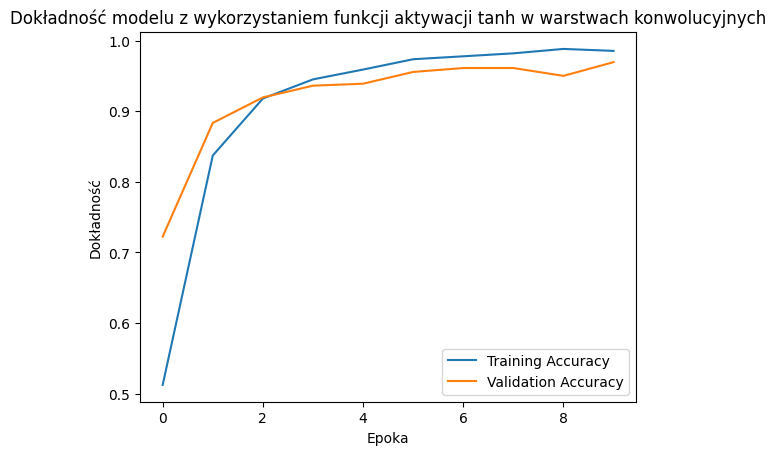

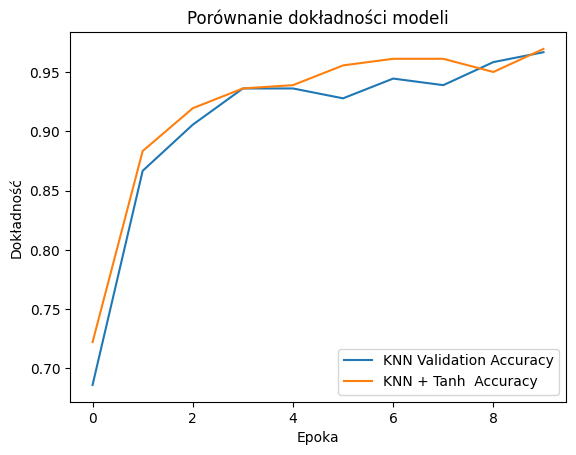

In [50]:
model_tanh = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), activation='tanh', input_shape=(8, 8, 1)),
tf.keras.layers.MaxPooling2D((2, 2)),
tf.keras.layers.Conv2D(64, (3, 3), activation='tanh'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

model_tanh.summary()

model_tanh.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_tanh = model_tanh.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

plt.plot(history_tanh.history['accuracy'], label='Training Accuracy')
plt.plot(history_tanh.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.title('Dokładność modelu z wykorzystaniem funkcji aktywacji tanh w warstwach konwolucyjnych')
plt.show()

plt.plot(history.history['val_accuracy'], label='KNN Validation Accuracy')
plt.plot(history_tanh.history['val_accuracy'], label='KNN + Tanh  Accuracy')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.title('Porównanie dokładności modeli')
plt.show()

Dodatkowo zrealizowana macierz pomyłek oraz przykładowe 9 źle sklasyfikowanych liczb


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step


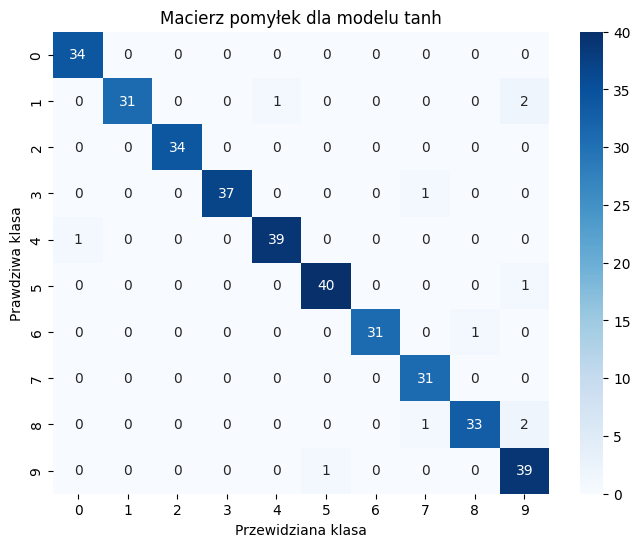

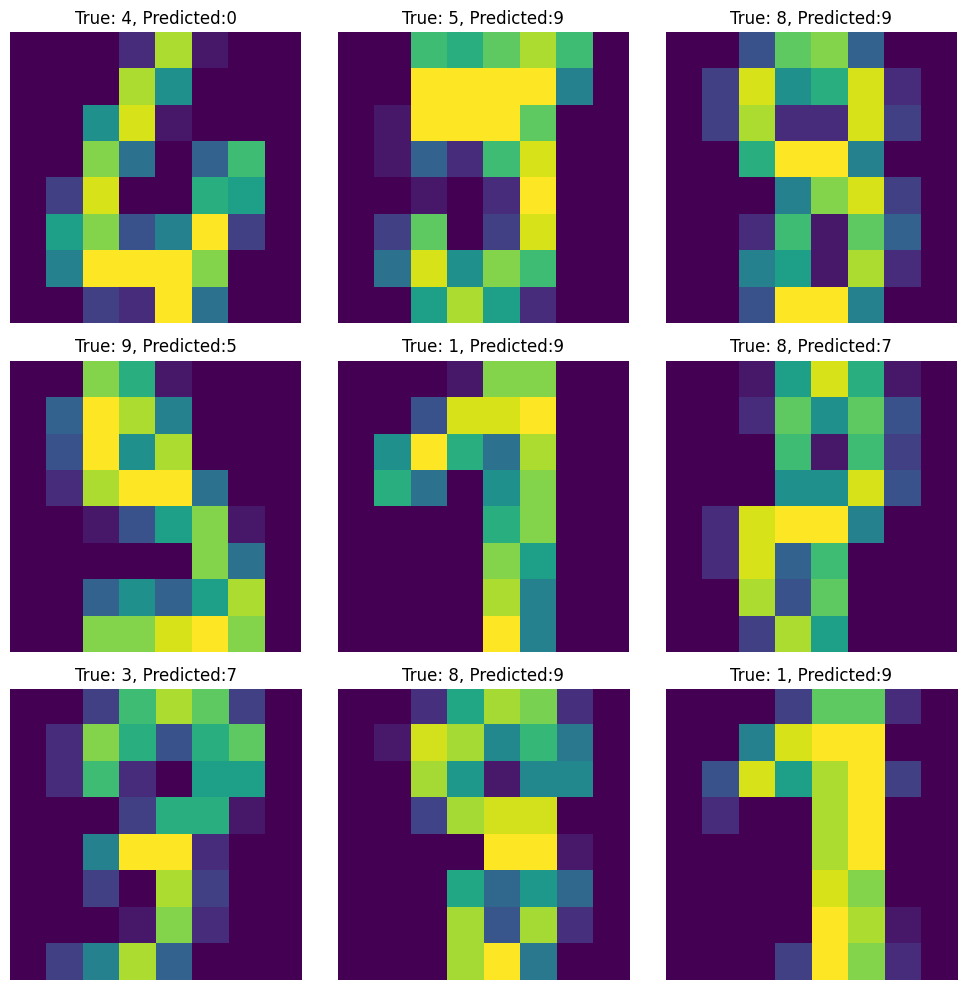

In [57]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model = model_tanh

y_pred_tanh = best_model.predict(X_test)
y_pred_max = tf.argmax(y_pred_tanh, axis=1)

cm = confusion_matrix(y_test, y_pred_max)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Przewidziana klasa')
plt.ylabel('Prawdziwa klasa')
plt.title('Macierz pomyłek dla modelu tanh')
plt.show()

wrong = np.where(y_pred_max != y_test)[0]
plt.figure(figsize=(10, 10))
for i, idx in enumerate(wrong[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])
    true_label = class_names[int(y_test[idx])]
    pred_label = class_names[int(y_pred_max[idx])]

    plt.title(f"True: {true_label}, Predicted:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()